#**Q4. Non-causal Transformer model using pretrained word2vec (CBOW or Skipgram and any vector size from 64 to 300) with position embeddings**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import nltk
from tqdm import tqdm
tqdm.pandas()

from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

import re
# import emoji
import multiprocessing

from multiprocessing import Pool

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import os
import warnings


#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Dropout, Dense, LayerNormalization,
                                     MultiHeadAttention, GlobalAveragePooling1D, Lambda)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from gensim.models import KeyedVectors
import gensim.downloader as api
import matplotlib.pyplot as plt

In [1]:
pip install tqdm

# Pre trained word2vec model with 300D

In [3]:
pip install Gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 re

In [3]:
sampled_df=pd.read_csv("preprocessed_data.csv")

In [ ]:
sampled_df.head()

,Tweet,Sentiment,Cleaned_Tweet,Spell_Checked_Tweet,Negated_Tweet,Contains_Emoji
0,Ottawa Police shoot RUBBER BULLETS into crowd ...,Positive,ottawa police shoot rubber bullets into crowd ...,ottawa police shoot rubber bullets into crowd ...,ottawa police shoot rubber bullets into crowd ...,False
1,A former Mountie and member of Prime Minister ...,Positive,a former mountie and member of prime minister ...,a former mountie and member of prime minister ...,a former mountie and member of prime minister ...,False
2,@PierrePoilievre It’s already the freest count...,Positive,its already the freest country stop trying to...,its already the freest country stop trying to ...,it s already the freest country stop trying to...,False
3,@RobynUrback Ban ministers from the Very progr...,Positive,ban ministers from the very progressive freed...,ban ministers from the very progressive freedo...,ban ministers from the very progressive freedo...,False
4,Three songs have been stuck in my head the pas...,Positive,three songs have been stuck in my head the pas...,three songs have been stuck in my head the pas...,three songs have been stuck in my head the pas...,False


In [4]:
sampled_df.isnull().sum()

,0
Tweet,0
Sentiment,0
Cleaned_Tweet,2
Spell_Checked_Tweet,0
Negated_Tweet,0
Contains_Emoji,0


In [ ]:
# sampled_df.to_csv("preprocessed_data.csv", index=False, encoding='utf-8')

# Data splitting

In [5]:
from sklearn.model_selection import train_test_split

# split into train (80%) and temp (20%)
train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.2,
    stratify=sampled_df["Sentiment"],
    random_state=42
)

# Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Sentiment"],
    random_state=42
)


print(f"Train: {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")
print(f"Test: {len(test_df)} rows")


Train: 84107 rows
Validation: 10513 rows
Test: 10514 rows


In [6]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# Label encoding Sentiment column

In [7]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Fitting
train_df['Sentiment'] = label_encoder.fit_transform(train_df['Sentiment'])

# Apply the same transformation to the validation and test sets
val_df['Sentiment'] = label_encoder.transform(val_df['Sentiment'])
test_df['Sentiment'] = label_encoder.transform(test_df['Sentiment'])


In [8]:
# label encoding for Positive, Negative, and Neutral
print("Label Encoding Mapping:")
for label, encoding in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label}: {encoding}")


Label Encoding Mapping:
Negative: 0
Neutral: 1
Positive: 2


In [ ]:
test_df.head()

,Tweet,Sentiment,Cleaned_Tweet,Spell_Checked_Tweet,Negated_Tweet,Contains_Emoji
0,"@CTVNews The pigs and the so-called ""freedom"" ...",0,the pigs and the socalled freedom convoy have...,the pigs and the socalled freedom convoy have ...,the pigs and the so called freedom convoy hav...,False
1,Banana Republics all over the world are callin...,1,banana republics all over the world are callin...,banana republics all over the world are callin...,banana republics all over the world are callin...,False
2,@FringedCanuck Just because she likes the PPC?...,2,just because she likes the ppc quit dividing ...,just because she likes the ppc quit dividing c...,just because she likes the ppc quit dividin...,False
3,Grande #Djokovic 👏👏👏\n\n#TrudeauTyranny \n\n#F...,1,grande,grand,grand,False
4,@DianaGlobalNews The simple truth is that if y...,1,the simple truth is that if you support the c...,the simple truth is that if you support the co...,the simple truth is that if you support the co...,False


# Tokenization and Padding

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer


vocab_size = 10000

# tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

# fitting on train data
tokenizer.fit_on_texts(train_df["Spell_Checked_Tweet"])





In [10]:

# maxlen = max([len(tweet.split()) for tweet in train_df["Negated_Tweet"]])
maxlen=150

# Converting texts to sequences
train_sequences = tokenizer.texts_to_sequences(train_df["Spell_Checked_Tweet"])
val_sequences = tokenizer.texts_to_sequences(val_df["Spell_Checked_Tweet"])
test_sequences = tokenizer.texts_to_sequences(test_df["Spell_Checked_Tweet"])

# Padding the sequences to the same length (maxlen)
train_sequences_padded = pad_sequences(train_sequences, maxlen=maxlen, padding='post', truncating='post')
val_sequences_padded = pad_sequences(val_sequences, maxlen=maxlen, padding='post', truncating='post')
test_sequences_padded = pad_sequences(test_sequences, maxlen=maxlen, padding='post', truncating='post')

print(f"Train sequences shape: {train_sequences_padded.shape}")
print(f"Validation sequences shape: {val_sequences_padded.shape}")
print(f"Test sequences shape: {test_sequences_padded.shape}")


Train sequences shape: (84107, 150)
Validation sequences shape: (10513, 150)
Test sequences shape: (10514, 150)


# Pretrained Google news Word2Vec with 300 dimensions

In [11]:
import gensim.downloader as api

# Load pretrained Word2Vec model
w2v_model = api.load("word2vec-google-news-300")
embedding_dim = w2v_model.vector_size


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [12]:
print(f"Total words in Word2Vec model: {len(w2v_model.key_to_index)}")

Total words in Word2Vec model: 3000000


In [13]:

# embedding matrix
vocab_size = min(10000, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        if word in w2v_model:
            embedding_matrix[idx] = w2v_model[word]
        else:
            # Random initialization for OOV words
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))


In [ ]:
# oov_words = []
# for word, idx in tokenizer.word_index.items():
#     if word not in w2v_model:
#         oov_words.append(word)

# # few OOV words
# print("OOV Words (not in pretrained Word2Vec model):")
# print(oov_words[:10])


OOV Words (not in pretrained Word2Vec model):
['<OOV>', 'a', 'to', 'of', 'and', 'trudeau', 'covid', 'notis', 'gofundme', 'notwas']


In [ ]:
covered = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size and word in w2v_model:
        covered += 1

print(f"Coverage: {covered / vocab_size:.2%}")


Coverage: 94.79%


#Basic Model 1

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models


from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Dropout, Dense, LayerNormalization,
                                     MultiHeadAttention, GlobalAveragePooling1D, Lambda)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from gensim.models import KeyedVectors
import gensim.downloader as api
import matplotlib.pyplot as plt

#  positional encoding layer
class PositionalEmbedding(layers.Layer):
    def __init__(self, vocab_size, embedding_dim, max_len, embedding_matrix, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_len = max_len
        self.embedding_matrix = embedding_matrix
        self.token_embed = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False,
        )
        self.pos_embed = layers.Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        maxlen = tf.shape(x)[1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_embed(positions)
        x = self.token_embed(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "embedding_dim": self.embedding_dim,
            "max_len": self.max_len,
            "embedding_matrix": self.embedding_matrix.tolist(), # Convert numpy array to list for serialization
        })
        return config

# Parameters
num_classes = 3
dropout_rate = 0.1

# Model
inputs = layers.Input(shape=(maxlen,))
x = PositionalEmbedding(vocab_size, embedding_dim, maxlen, embedding_matrix)(inputs)

# Transformer block
attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=embedding_dim)(x, x)
x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
ff_output = layers.Dense(128, activation='relu')(x)
ff_output = layers.Dense(embedding_dim)(ff_output)
x = layers.LayerNormalization(epsilon=1e-6)(x + ff_output)

# Pooling + Dense
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 150, 300)  │  3,045,000 │ input_layer[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 150, 300)  │    722,100 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 300)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 150, 300)  │        600 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 150, 128)  │     38,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 150, 300)  │     38,700 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 150, 300)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 150, 300)  │        600 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 300)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     19,264 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,864,987 (14.74 MB)

 Trainable params: 864,987 (3.30 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [16]:
# Train the model
history = model.fit(
    train_sequences_padded,
    train_df["Sentiment"],
    validation_data=(val_sequences_padded, val_df["Sentiment"]),
    epochs=15,
    batch_size=64,
    verbose=1
)


Epoch 1/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.5337 - loss: 0.9630 - val_accuracy: 0.6173 - val_loss: 0.8223
Epoch 2/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - accuracy: 0.6098 - loss: 0.8413 - val_accuracy: 0.6294 - val_loss: 0.8064
Epoch 3/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6255 - loss: 0.8159 - val_accuracy: 0.6367 - val_loss: 0.7919
Epoch 4/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.6364 - loss: 0.7934 - val_accuracy: 0.6432 - val_loss: 0.7921
Epoch 5/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6412 - loss: 0.7862 - val_accuracy: 0.6325 - val_loss: 0.7941
Epoch 6/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6523 - loss: 0.7737 - val_accuracy: 0.6598 - val_loss: 0.7643
Epoch 7/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6586 - loss: 0.7629 - val_accuracy: 0.6579 - val_loss: 0.7534
Epoch 8/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.6668 -

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelBinarizer
import numpy as np

def evaluate_model(model, data, labels, data_name="Data"):


    preds = model.predict(data)

    # predicted class labels
    preds_class = np.argmax(preds, axis=1)

    # Accuracy
    acc = accuracy_score(labels, preds_class)
    print(f"{data_name} Accuracy: {acc:.4f}")

    # F1 Score (Macro Average)
    f1 = f1_score(labels, preds_class, average='macro')
    print(f"{data_name} Macro F1 Score: {f1:.4f}")

    # Macro AUC Score (One-vs-Rest)
    auc_score = roc_auc_score(labels, preds, multi_class='ovr', average='macro')
    print(f"{data_name} Macro AUC Score: {auc_score:.4f}")

    # Classification Report
    print(f"{data_name} Classification Report:")
    print(classification_report(labels, preds_class))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds_class)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"{data_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve and AUC for each class
    lb = LabelBinarizer()
    labels_bin = lb.fit_transform(labels)

    plt.figure(figsize=(8, 6))
    for i in range(labels_bin.shape[1]):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], preds[:, i])  # ROC for each class
        auc = roc_auc_score(labels_bin[:, i], preds[:, i])  # AUC for the class
        print(f"{data_name} Class {i} AUC: {auc:.4f}")

        plt.plot(fpr, tpr, label=f'Class {i} ROC curve (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{data_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()




2629/2629 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Train Accuracy: 0.7020
Train Macro F1 Score: 0.6984
Train Macro AUC Score: 0.8728
Train Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.79      0.72     27984
           1       0.79      0.55      0.65     28144
           2       0.69      0.76      0.72     27979

    accuracy                           0.70     84107
   macro avg       0.71      0.70      0.70     84107
weighted avg       0.71      0.70      0.70     84107



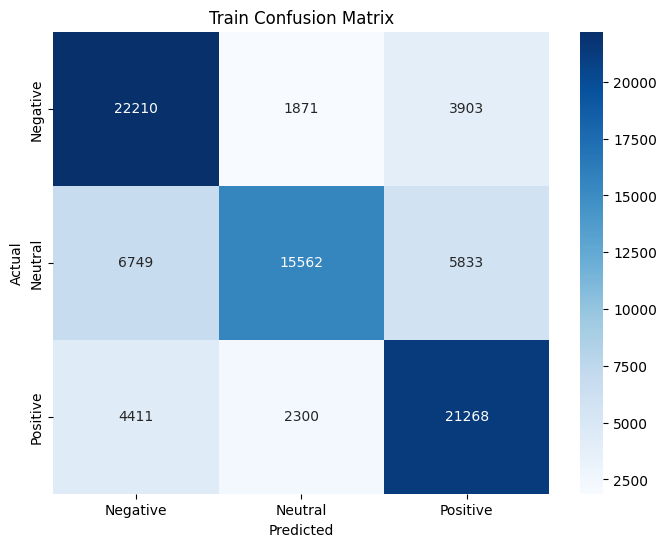

Train Class 0 AUC: 0.8916
Train Class 1 AUC: 0.8408
Train Class 2 AUC: 0.8859


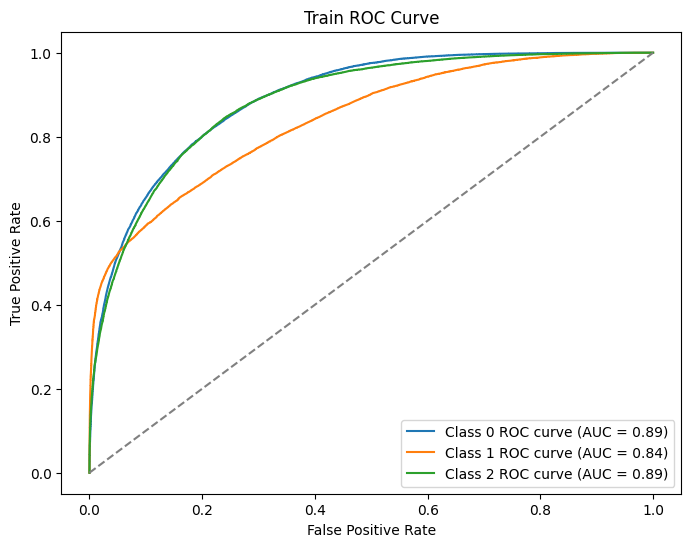

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test Accuracy: 0.6792
Test Macro F1 Score: 0.6762
Test Macro AUC Score: 0.8508
Test Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.76      0.70      3498
           1       0.76      0.54      0.63      3518
           2       0.66      0.74      0.70      3498

    accuracy                           0.68     10514
   macro avg       0.69      0.68      0.68     10514
weighted avg       0.69      0.68      0.68     10514



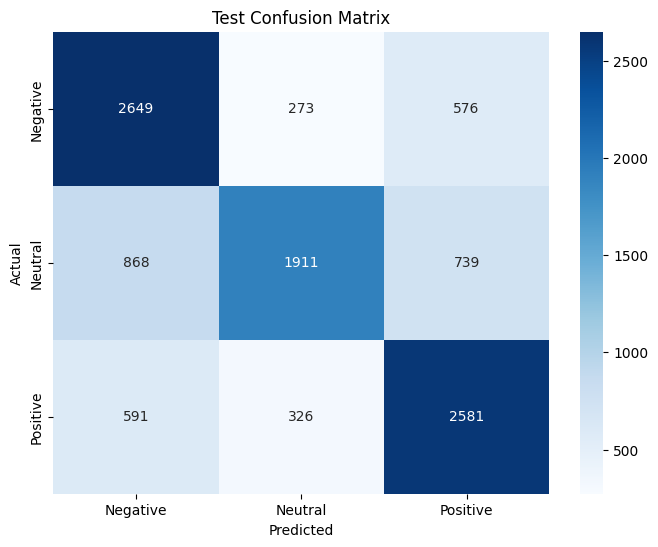

Test Class 0 AUC: 0.8674
Test Class 1 AUC: 0.8201
Test Class 2 AUC: 0.8649


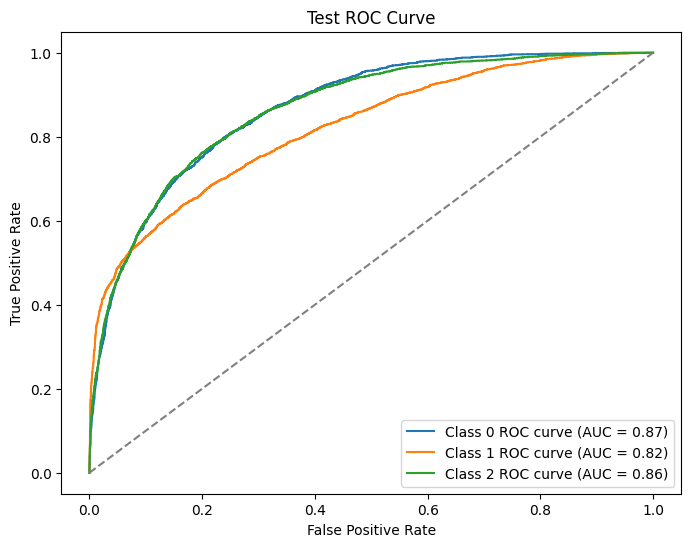

In [18]:
# Evaluation
evaluate_model(model, train_sequences_padded, train_df["Sentiment"], "Train")

evaluate_model(model, test_sequences_padded, test_df["Sentiment"], "Test")


# Model

1. Adding weightage to neutral class


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau


from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Dropout, Dense, LayerNormalization,
                                     MultiHeadAttention, GlobalAveragePooling1D, Lambda)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from gensim.models import KeyedVectors
import gensim.downloader as api
import matplotlib.pyplot as plt

# #  positional encoding layer
# class PositionalEmbedding(layers.Layer):
#     def __init__(self, vocab_size, embedding_dim, max_len, embedding_matrix):
#         super().__init__()
#         self.token_embed = layers.Embedding(
#             input_dim=vocab_size,
#             output_dim=embedding_dim,
#             weights=[embedding_matrix],
#             trainable=False,
#         )
#         self.pos_embed = layers.Embedding(input_dim=max_len, output_dim=embedding_dim)

#     def call(self, x):
#         maxlen = tf.shape(x)[1]
#         positions = tf.range(start=0, limit=maxlen, delta=1)
#         positions = self.pos_embed(positions)
#         x = self.token_embed(x)
#         return x + positions


class PositionalEmbedding(layers.Layer):
    def __init__(self, vocab_size, embedding_dim, max_len, embedding_matrix, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_len = max_len
        self.embedding_matrix = embedding_matrix

        self.token_embed = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False
        )
        self.pos_embed = layers.Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        maxlen = tf.shape(x)[1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_embed(positions)
        x = self.token_embed(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            'vocab_size': self.vocab_size,
            'embedding_dim': self.embedding_dim,
            'max_len': self.max_len,

        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config, embedding_matrix=None)

# Parameters
num_classes = 3
dropout_rate = 0.1

# Model
inputs = layers.Input(shape=(maxlen,))
x = PositionalEmbedding(vocab_size, embedding_dim, maxlen, embedding_matrix)(inputs)

# Transformer block
attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=embedding_dim)(x, x)
x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
ff_output = layers.Dense(128, activation='relu')(x)
ff_output = layers.Dense(embedding_dim)(ff_output)
x = layers.LayerNormalization(epsilon=1e-6)(x + ff_output)

# Pooling + Dense
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model1 = models.Model(inputs=inputs, outputs=outputs)
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

class_weights = {
    0: 1.0,  # Negative
    1: 1.2,  # Neutral
    2: 1.0   # Positive
}

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)




model1.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 150, 300)  │  3,045,000 │ input_layer_4[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 150, 300)  │    722,100 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 150, 300)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 150, 300)  │        600 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 150, 128)  │     38,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 150, 300)  │     38,700 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 150, 300)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 150, 300)  │        600 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 300)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │     19,264 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 3)         │        195 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,864,987 (14.74 MB)

 Trainable params: 864,987 (3.30 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [33]:
# Train the model
history = model1.fit(
    train_sequences_padded,
    train_df["Sentiment"],
    validation_data=(val_sequences_padded, val_df["Sentiment"]),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[reduce_lr],
    verbose=1
)


Epoch 1/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.5312 - loss: 1.0172 - val_accuracy: 0.6204 - val_loss: 0.8274 - learning_rate: 0.0010
Epoch 2/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 75s 31ms/step - accuracy: 0.6085 - loss: 0.8980 - val_accuracy: 0.6320 - val_loss: 0.7993 - learning_rate: 0.0010
Epoch 3/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6215 - loss: 0.8708 - val_accuracy: 0.6363 - val_loss: 0.8014 - learning_rate: 0.0010
Epoch 4/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.6337 - loss: 0.8524 - val_accuracy: 0.6435 - val_loss: 0.7823 - learning_rate: 0.0010
Epoch 5/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.6410 - loss: 0.8399 - val_accuracy: 0.6326 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 6/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.6447 - loss: 0.8302 - val_accuracy: 0.6491 - val_loss: 0.7761 - learning_rate: 0.0010
Epoch 7/15
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accura

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Train Accuracy: 0.7109
Train Macro F1 Score: 0.7096
Train Macro AUC Score: 0.8818
Train Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     27984
           1       0.73      0.63      0.67     28144
           2       0.68      0.79      0.73     27979

    accuracy                           0.71     84107
   macro avg       0.71      0.71      0.71     84107
weighted avg       0.71      0.71      0.71     84107



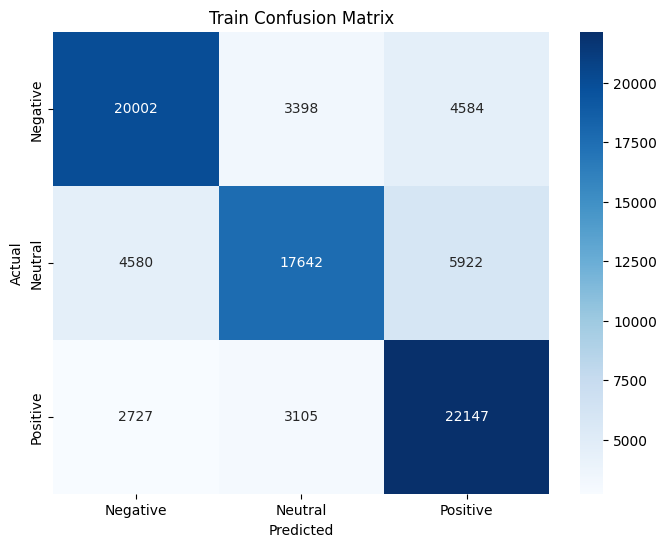

Train Class 0 AUC: 0.8969
Train Class 1 AUC: 0.8569
Train Class 2 AUC: 0.8917


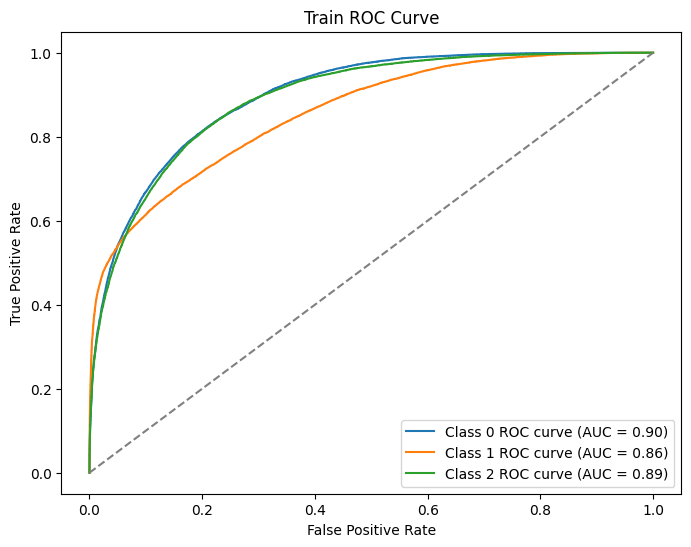

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Test Accuracy: 0.6800
Test Macro F1 Score: 0.6789
Test Macro AUC Score: 0.8537
Test Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.67      0.69      3498
           1       0.69      0.61      0.65      3518
           2       0.65      0.76      0.70      3498

    accuracy                           0.68     10514
   macro avg       0.68      0.68      0.68     10514
weighted avg       0.68      0.68      0.68     10514



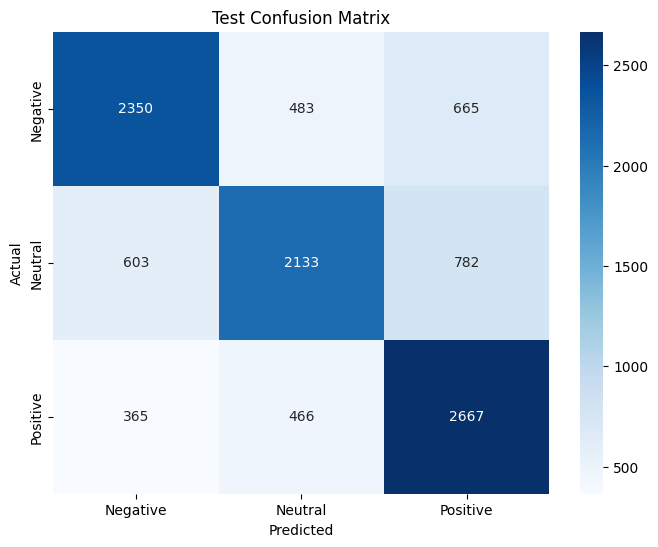

Test Class 0 AUC: 0.8708
Test Class 1 AUC: 0.8231
Test Class 2 AUC: 0.8671


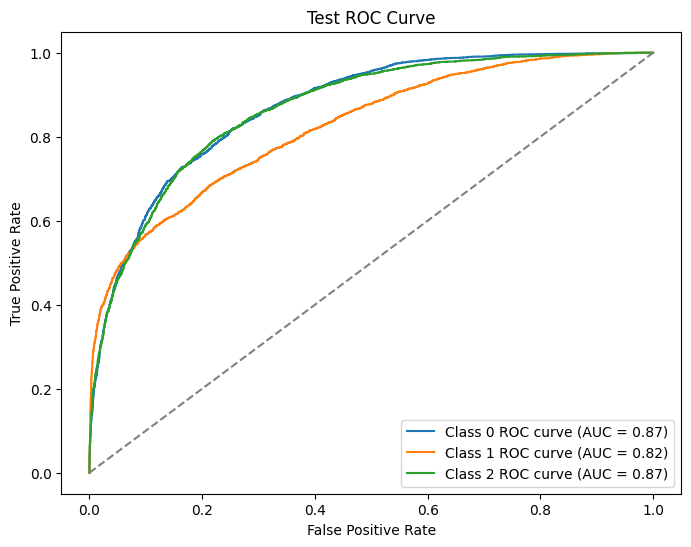

In [34]:
# Evaluation
evaluate_model(model1, train_sequences_padded, train_df["Sentiment"], "Train")

evaluate_model(model1, test_sequences_padded, test_df["Sentiment"], "Test")


**After increasing weightage, now all classes have decent f1 score on test data. Improved a lot from previous base model.**

In [30]:
# import pickle

# with open('tokenizer.pkl', 'wb') as f:
#     pickle.dump(tokenizer, f)


In [31]:
# label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
# with open('label_map.pkl', 'wb') as f:
#     pickle.dump(label_map, f)


In [35]:
model1.save("transformer_sentiment_model.keras")
